In [2]:
import pandas as pd

In [5]:
inter_path = '/Users/alesy/kursach/data/fetched/audio_features.parquet'
inter = pd.read_parquet(inter_path)

print(inter.shape)
inter.head()

(10540, 15)


,song_id,deezer_id,language_code,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,timeSignature,valence
0,SOBONKR12A58A7A7E0,672032,en,0.39,0.56,0.49,0.00,7,0.09,-5.02,1,0.03,95.69,3,0.32
1,SOAUWYT12A81C206F1,2629696692,en,0.78,0.40,0.37,0.01,2,0.12,-12.01,0,0.04,115.40,4,0.05
2,SOSXLTC12AF72A7F54,15531173,en,0.20,0.44,0.75,0.00,4,0.16,-6.59,1,0.07,149.83,4,0.38
3,SOFRQTD12A81C233C0,438288652,,0.09,0.18,0.48,0.92,4,0.09,-18.03,1,0.21,151.08,5,0.27
4,SOAXGDH12A8C13F8A1,7561772,en,0.04,0.50,0.80,0.00,7,0.12,-5.29,1,0.08,149.97,4,0.36


In [3]:
inter_path = '/Users/alesy/kursach/data/interactions_full.parquet'
inter = pd.read_parquet(inter_path)

print(inter.shape)
inter.head()

(48373586, 3)


,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAPDEY12A81C210A9,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFNSP12AF72A0E22,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFOVM12A58A7D494,1


In [3]:
inter.columns

Index(['user_id', 'song_id', 'play_count', 'deezer_id', 'name', 'artists',
       'genre_root', 'genre_sub', 'duration', 'release_date', 'explicit',
       'language_code', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'timeSignature', 'valence'],
      dtype='object')

In [5]:
inter['user_id'].nunique()

1012802

In [22]:
users_path = '/Users/alesy/kursach/data/user_songs.parquet'
users = pd.read_parquet(users_path)

print(users.shape)
users.head()

(48373586, 3)


,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAPDEY12A81C210A9,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFNSP12AF72A0E22,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFOVM12A58A7D494,1


In [62]:
song_pop = users.groupby('song_id')['play_count'].sum().sort_values(ascending=False)
top50k = song_pop.head(11000).index
coverage = users[users['song_id'].isin(top50k)].shape[0] / len(users)
print(f'Top-50k songs cover {coverage:.1%} of interactions')

Top-50k songs cover 54.9% of interactions


In [54]:
msd_path = '/Users/alesy/kursach/data/raw/msd_songs.parquet'
msd = pd.read_parquet(msd_path)
msd = msd.drop(columns=[c for c in msd.columns if c.startswith('idx_')])

print(msd.shape)
print(msd.head())

(10000, 19)
              song_id                                  title  \
0  SOGSMXL12A81C23D88         Je Sais Que La Terre Est Plate   
1  SOMBCOW12AAF3B229F                              On Efface   
2  SOEYIHF12AB017B5F4                        Howells Delight   
3  SODJYEC12A8C13D757                          Martha Served   
4  SOGSOUE12A58A76443  Zip-A-Dee-Doo-Dah (Song of the South)   

                   artist  analysis_sample_rate  \
0                 Raphaël                 22050   
1           Julie Zenatti                 22050   
2   The Baltimore Consort                 22050   
3            I Hate Sally                 22050   
4  Orlando Pops Orchestra                 22050   

                             audio_md5  danceability   duration  \
0  b'd8bafd4a65d1855aec08991c8b013dc1'           0.0  148.74077   
1  b'55f60c97280172e9276723c06e531996'           0.0  252.99546   
2  b'053fb50807248bef996e6c7a5fe93533'           0.0   78.02730   
3  b'1637df8efe4d89507b6f4ef

In [57]:
all_songs_path = '/Users/alesy/kursach/data/raw/unique_tracks.txt'
all_songs = pd.read_csv(all_songs_path,  sep="<SEP>",
    header=None,
    names=["track_id", "song_id", "artist", "title"]
)
all_songs =all_songs.drop_duplicates('song_id')

/var/folders/30/9t0lpd4x4kl9cc94r8mw4kp80000gn/T/ipykernel_80197/714670086.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  all_songs = pd.read_csv(all_songs_path,  sep="<SEP>",


In [58]:
to_fetch = top50k[~top50k.isin(msd['song_id'])]   # ~49 366 песен
to_fetch_meta = (all_songs.drop_duplicates('song_id')
                 .set_index('song_id')
                 .loc[to_fetch, ['artist', 'title']]
                 .reset_index())
to_fetch_meta.to_csv('data/to_fetch.csv', index=False)
print(to_fetch_meta.shape)

(49366, 3)


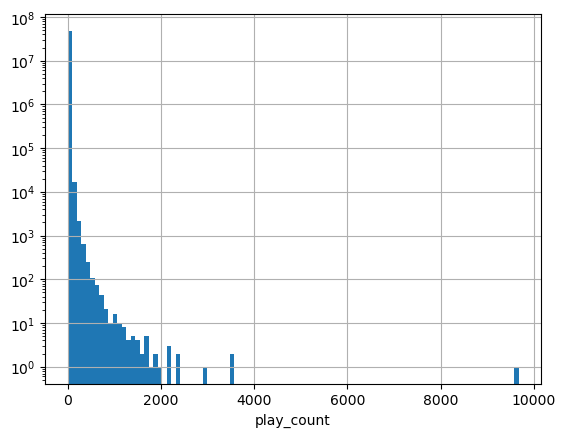

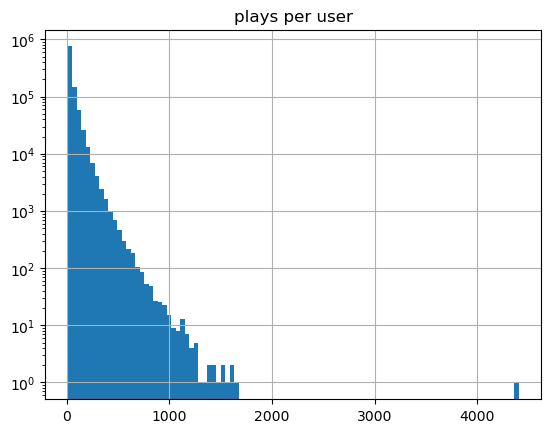

count    1.019318e+06
mean     4.745682e+01
std      5.781573e+01
min      1.000000e+01
25%      1.600000e+01
50%      2.700000e+01
75%      5.500000e+01
max      4.400000e+03
dtype: float64


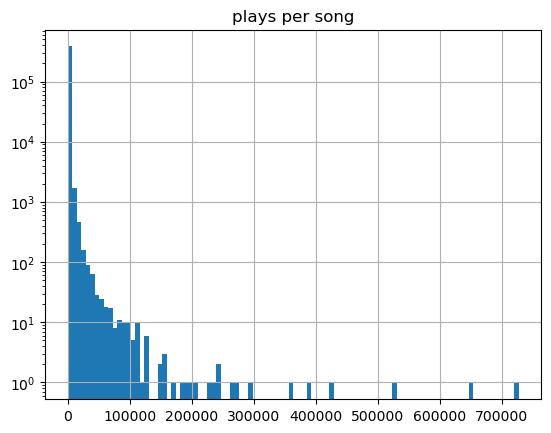

sparsity: 1.23e-04


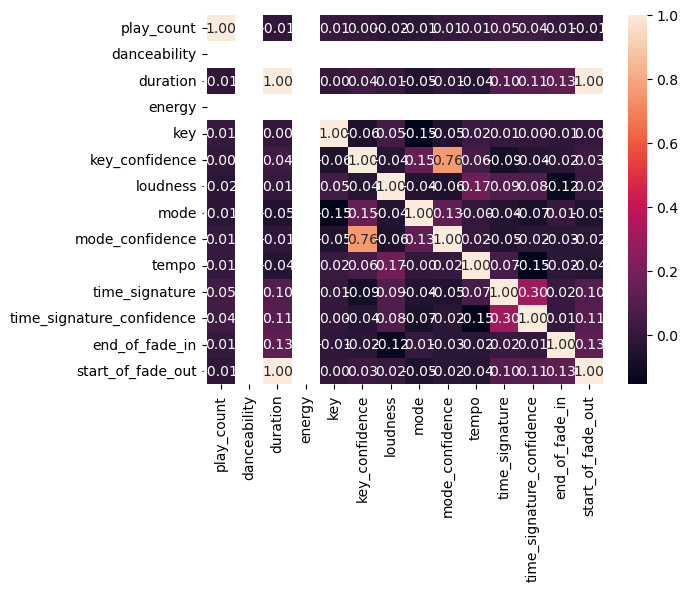

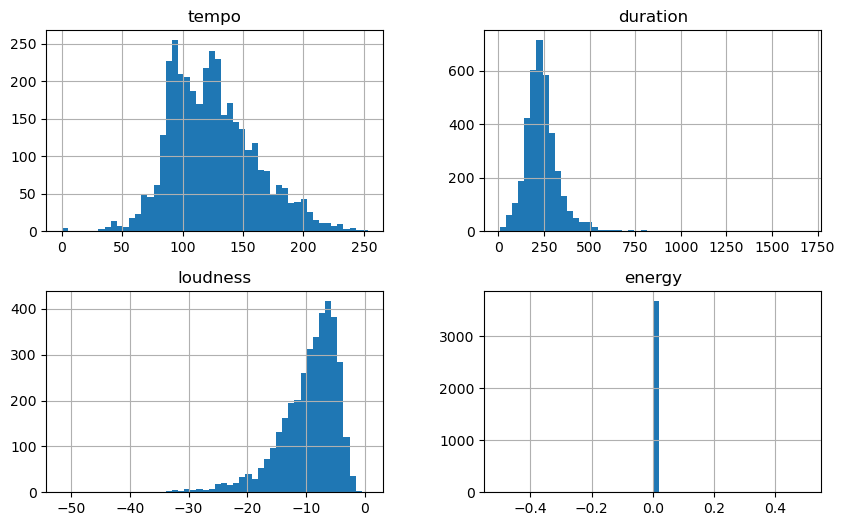

(np.int64(0), np.int64(4))

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. play_count
users['play_count'].describe()
users['play_count'].hist(bins=100, log=True); plt.xlabel('play_count'); plt.show()

# 2. активность пользователей
user_activity = users.groupby('user_id').size()
user_activity.hist(bins=100, log=True); plt.title('plays per user'); plt.show()
print(user_activity.describe())

# 3. популярность песен
song_pop = users.groupby('song_id')['play_count'].sum()
song_pop.hist(bins=100, log=True); plt.title('plays per song'); plt.show()

# 4. sparsity
n_users, n_songs = users['user_id'].nunique(), users['song_id'].nunique()
print(f'sparsity: {len(users) / (n_users * n_songs):.2e}')

# 5. аудио-фичи
audio_num = interactions_audio.drop_duplicates('song_id').select_dtypes('number')
sns.heatmap(audio_num.corr(), annot=True, fmt='.2f'); plt.show()
audio_num[['tempo','duration','loudness','energy']].hist(bins=50, figsize=(10,6)); plt.show()
(audio_num['duration'] == 0).sum(), (audio_num['tempo'] == 0).sum()


In [46]:
audio_cols = ['song_id', 'artist', 'title', 'danceability','duration','energy','key','key_confidence',
              'loudness','mode','mode_confidence','tempo','time_signature',
              'time_signature_confidence','end_of_fade_in','start_of_fade_out']
msd_clean = msd[audio_cols].drop_duplicates('song_id')

interactions_audio = users.merge(msd_clean, on='song_id', how='inner').dropna()
# interactions_audio.to_parquet('data/interactions_audio.parquet', index=False)
print(interactions_audio.shape)
print(interactions_audio['song_id'].nunique())
print(interactions_audio.head())
interactions_audio.to_parquet('data/interactions_audio.parquet', index=False)

(772661, 18)
3675
                                    user_id             song_id  play_count  \
0  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOWEZSI12A81C21CE6           1   
1  4bd88bfb25263a75bbdd467e74018f4ae570e5df  SODCXXY12AB0187452           2   
2  4bd88bfb25263a75bbdd467e74018f4ae570e5df  SOWPAXV12A67ADA046          18   
3  b64cdd1a0bd907e5e00b39e345194768e330d652  SOLXDDC12A6701FBFD           1   
4  b64cdd1a0bd907e5e00b39e345194768e330d652  SONJBQX12A6D4F8382           4   

        artist              title  danceability   duration  energy  key  \
0  Gipsy Kings  Tu Quieres Volver           0.0  194.87302     0.0    5   
1   brokeNCYDE            Freaxxx           0.0  214.98730     0.0    1   
2  Salt-N-Pepa            Push It           0.0  207.62077     0.0    4   
3       Eminem           I'm Back           0.0  312.26730     0.0   11   
4    Daft Punk            Da Funk           0.0  329.53424     0.0    5   

   key_confidence  loudness  mode  mode_confidence    te

In [24]:
# 1. Оставим топ N пользователей по активности
top_users = users['user_id'].value_counts().head(10000).index
users_small = users[users['user_id'].isin(top_users)]

# 2. Оставим только песни, которые слушали эти пользователи
top_songs = users_small['song_id'].unique()
users_small = users_small[users_small['song_id'].isin(top_songs)]

print("Количество строк в тестовом датасете:", len(users_small))
print("Уникальных пользователей:", users_small['user_id'].nunique())
print("Уникальных песен:", users_small['song_id'].nunique())

Количество строк в тестовом датасете: 4017204
Уникальных пользователей: 10000
Уникальных песен: 248418


In [ ]:
all_songs_path = '/Users/alesy/kursach/data/unique_tracks.txt'
all_songs = pd.read_csv(all_songs_path,  sep="<SEP>",
    header=None,
    names=["track_id", "song_id", "artist", "title"]
)
all_songs =all_songs.drop_duplicates('song_id')

/var/folders/30/9t0lpd4x4kl9cc94r8mw4kp80000gn/T/ipykernel_80197/956291455.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  all_songs = pd.read_csv(all_songs_path,  sep="<SEP>",


## dataset of user interactions with songs

In [39]:
df = users.merge(all_songs, on="song_id", how="inner")
df.dropna()
print(df.shape)
print(df.columns)

(48373586, 6)
Index(['user_id', 'song_id', 'play_count', 'track_id', 'artist', 'title'], dtype='object')


In [27]:
df.head(5)

,user_id,song_id,play_count,track_id,artist,title
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1,TRIQAUQ128F42435AD,Jack Johnson,The Cove
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAPDEY12A81C210A9,1,TRIRLYL128F42539D1,Billy Preston,Nothing from Nothing
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2,TRMHBXZ128F4238406,Paco De Lucia,Entre Dos Aguas
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFNSP12AF72A0E22,1,TRYQMNI128F147C1C7,Josh Rouse,Under Cold Blue Stars
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFOVM12A58A7D494,1,TRAHZNE128F9341B86,The Dead 60s,Riot Radio (Soundtrack Version)


In [28]:
audiofeatures_join = df.merge(msd, on="song_id", how="inner")
print(audiofeatures_join.shape)
print(audiofeatures_join.head(5))


(923779, 39)
                                    user_id             song_id  play_count  \
0  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOWEZSI12A81C21CE6           1   
1  4bd88bfb25263a75bbdd467e74018f4ae570e5df  SODCXXY12AB0187452           2   
2  4bd88bfb25263a75bbdd467e74018f4ae570e5df  SOWPAXV12A67ADA046          18   
3  b64cdd1a0bd907e5e00b39e345194768e330d652  SOLXDDC12A6701FBFD           1   
4  b64cdd1a0bd907e5e00b39e345194768e330d652  SONJBQX12A6D4F8382           4   

           track_id_x     artist_x            title_x            title_y  \
0  TRAUCNU128F42671EB  Gipsy Kings  Tu Quieres Volver  Tu Quieres Volver   
1  TRBFXMJ12903CB50F6   brokeNCYDE            Freaxxx            Freaxxx   
2  TRBBMHE128EF341D09  Salt-N-Pepa            Push It            Push It   
3  TRAUURC128E078EC6E       Eminem           I'm Back           I'm Back   
4  TRAQVTO128F14696A6    Daft Punk            Da Funk            Da Funk   

      artist_y  analysis_sample_rate                   

In [34]:
print(audiofeatures_join['song_id'].nunique())
print(audiofeatures_join.columns)

3675
Index(['user_id', 'song_id', 'play_count', 'track_id_x', 'artist_x', 'title_x',
       'title_y', 'artist_y', 'analysis_sample_rate', 'audio_md5',
       'danceability', 'duration', 'end_of_fade_in', 'energy',
       'idx_bars_confidence', 'idx_bars_start', 'idx_beats_confidence',
       'idx_beats_start', 'idx_sections_confidence', 'idx_sections_start',
       'idx_segments_confidence', 'idx_segments_loudness_max',
       'idx_segments_loudness_max_time', 'idx_segments_loudness_start',
       'idx_segments_pitches', 'idx_segments_start', 'idx_segments_timbre',
       'idx_tatums_confidence', 'idx_tatums_start', 'key', 'key_confidence',
       'loudness', 'mode', 'mode_confidence', 'start_of_fade_out', 'tempo',
       'time_signature', 'time_signature_confidence', 'track_id_y'],
      dtype='object')


In [30]:
matching_songs = df["song_id"].nunique()

In [31]:
total_songs_in_subset = all_songs['track_id'].nunique()
matching_songs = df["song_id"].nunique()
songs_in_users = users['song_id'].nunique()

print(f'Unique songs in users: {songs_in_users}')
print(f"Songs in unique: {total_songs_in_subset}")
print(f"Coverage: {matching_songs/total_songs_in_subset:.2%}")

Unique songs in users: 384546
Songs in unique: 1000000
Coverage: 38.45%


In [32]:
features_join = users.merge(songs, on="song_id", how="inner")
songs_features_join = features_join['song_id'].nunique()
print(f'Users and audio features overlap: {songs_features_join}')

NameError: name 'songs' is not defined

In [ ]:
print(f'How many requests do I need?? {songs_in_users - songs_features_join}')

How many requests do I need?? 380871


In [48]:
print(pd.read_parquet('data/interactions_audio.parquet'))

                                         user_id             song_id  \
0       b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOWEZSI12A81C21CE6   
1       4bd88bfb25263a75bbdd467e74018f4ae570e5df  SODCXXY12AB0187452   
2       4bd88bfb25263a75bbdd467e74018f4ae570e5df  SOWPAXV12A67ADA046   
3       b64cdd1a0bd907e5e00b39e345194768e330d652  SOLXDDC12A6701FBFD   
4       b64cdd1a0bd907e5e00b39e345194768e330d652  SONJBQX12A6D4F8382   
...                                          ...                 ...   
772656  8305c896f42308824da7d4386f4b9ee584281412  SOQHWMN12A6701E2D9   
772657  8305c896f42308824da7d4386f4b9ee584281412  SOSQIHH12A8C13370B   
772658  8305c896f42308824da7d4386f4b9ee584281412  SOUCKDH12A8C138FF5   
772659  8305c896f42308824da7d4386f4b9ee584281412  SOULTKQ12AB018A183   
772660  cf8289419383259189afe6bb50c5115fd84f1064  SOIZLKI12A6D4F7B61   

        play_count        artist  \
0                1   Gipsy Kings   
1                2    brokeNCYDE   
2               18   Salt-N